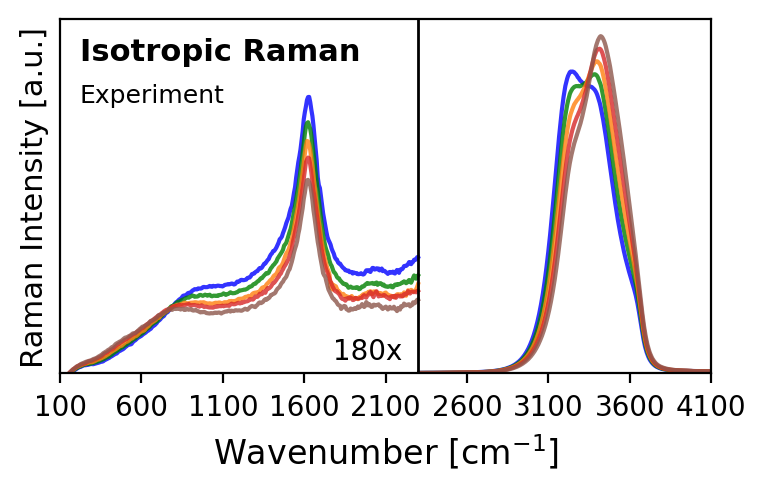

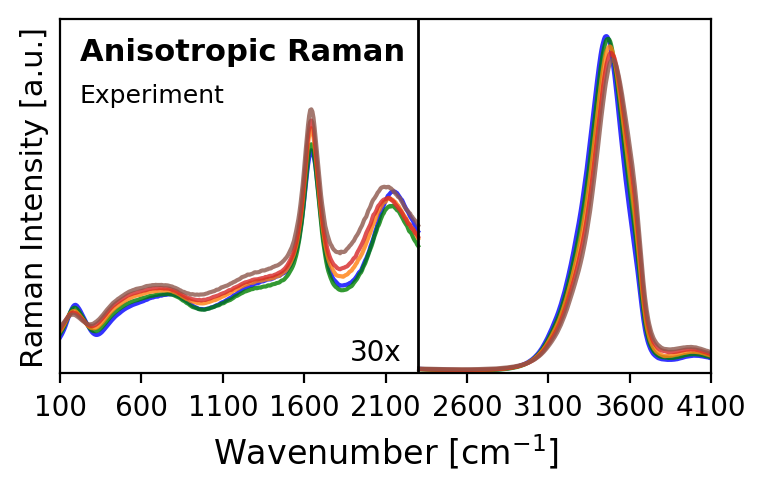

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. Visualization & Parameters
# ==========================================
n_scale_iso_exp = 180   
n_scale_aniso_exp = 30   
split_point = 2300       # Boundary for magnification (cm^-1)

temps = ['280', '300', '320', '340', '360']

import matplotlib.cm as cm
colors = ['blue', 'green', 'tab:orange', 'tab:red', 'tab:brown']

# ==========================================
# 2. Data Processing Function
# ==========================================
def process_experimental_data(csv_path, n_scale, split_x):
    df = pd.read_csv(csv_path, skiprows=3)
    x_col = df.columns[0]
    df = df[df[x_col] >= 100.0].copy()
    v = df[x_col].values

    h = 6.62607015e-34     
    c_cm = 2.99792458e10   
    kB = 1.380649e-23      
    v_0 = 1e7 / 514.532    
    freq_factor = v_0 * (v_0 - v)**3
    
    exp_dict = {}
    for temp_str in temps:
        T = float(temp_str)
        raw_intensity = df[temp_str].values
        
        # R(w)
        B_v = 1.0 - np.exp(-(h * c_cm * v) / (kB * T))
        reduced_intensity = raw_intensity * B_v * v / freq_factor
        
        # Area Normalization
        area = np.trapz(reduced_intensity, x=v)
        norm_intensity = reduced_intensity / area
        
        # Low/High
        y_low = norm_intensity * n_scale
        y_high = norm_intensity.copy()
        
        exp_dict[f"{temp_str} K"] = (y_low, y_high)
        
    return v, exp_dict

# ==========================================
# 3. Data Loading
# ==========================================
# csv files available in SI of doi/10.1002/jrs.5465 (Pattenaude et al.)
path_iso = './raman_csv/jrs5465-sup-0003-s3_h2o_isotropic_vs_t.csv' 
path_aniso = './raman_csv/jrs5465-sup-0004-s4_h2o_isotropic_vs_t.csv' 

exp_v, exp_iso_dict = process_experimental_data(path_iso, n_scale_iso_exp, split_point)
_, exp_aniso_dict = process_experimental_data(path_aniso, n_scale_aniso_exp, split_point)

# ==========================================
# 4. Plotting
# ==========================================
def plot_raman_experiment(v, exp_dict, title, scale_val, colors):
    fig, ax = plt.subplots(figsize=(4.2, 2.3), dpi=200)
    djvfont = {'fontname':'DejaVu Sans'}
    fs = 12
    
    def plot_split(x, y_low, y_high, color='black', label=None, alpha=0.8, linewidth=1.5):
        mask_low = x <= split_point + 2.5
        mask_high = x >= split_point
        ax.plot(x[mask_low], y_low[mask_low], color=color, alpha=alpha, linewidth=linewidth, label=label)
        ax.plot(x[mask_high], y_high[mask_high], color=color, alpha=alpha, linewidth=linewidth)
        return max(np.max(y_low[mask_low]), np.max(y_high[mask_high]))

    max_y = 0
    for (name, (y_low, y_high)), color in zip(exp_dict.items(), colors):
        m_max = plot_split(v, y_low, y_high, color=color, label=name)
        max_y = max(max_y, m_max)

    ax.axvline(x=split_point, color='black', linewidth=1, zorder=3)
    
    all_low_vals = [np.max(y_low[v <= split_point]) for y_low, y_high in exp_dict.values()]
    text_y = np.max(all_low_vals) * 0.05
    
    ax.text(split_point - 100, text_y, f'{scale_val}x', fontsize=10, color='black', ha='right')
    ax.text(0.03, 0.95, title, transform=ax.transAxes, fontsize=fs-1, 
            fontweight='bold', va='top', ha='left', **djvfont)
    ax.text(0.03, 0.82, "Experiment", transform=ax.transAxes, fontsize=fs-3, 
            va='top', ha='left', **djvfont)


    ax.set_xlabel("Wavenumber [cm$^{-1}$]", fontsize=fs, **djvfont)
    ax.set_ylabel("Raman Intensity [a.u.]", fontsize=fs-1, **djvfont)
    
    ax.set_xlim(100, 4100)
    ax.set_xticks([100, 600, 1100, 1600, 2100, 2600, 3100, 3600, 4100])
    
    ax.set_ylim(0, max_y * 1.05)
    ax.set_yticks([])

    # plt.savefig(f'water_figures/{title}_exp_temp_anotherexp.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 5. Execute Plotting
# ==========================================
plot_raman_experiment(exp_v, exp_iso_dict, title='Isotropic Raman', scale_val=n_scale_iso_exp, colors=colors)
plot_raman_experiment(exp_v, exp_aniso_dict, title='Anisotropic Raman', scale_val=n_scale_aniso_exp, colors=colors)